In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from xgboost import XBClassifier, XGBClassifier
import warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

Load Data

In [8]:
COLUMNS = [
    'fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class'
]
df = pd.read_csv('magic04.data', header=None, names=COLUMNS)
df['class'] = (df['class'].str.strip() == 'g').astype(int) #1=gamma, 0=hadron

print(df.shape)
df.head()

(19020, 11)


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


In [9]:
print(df['class'].value_counts().rename({1:'gamma', 0:'hadron'}))
print(f'\nGamma ratio: {df["class"].mean():.2%}')
df.describe()

class
gamma     12332
hadron     6688
Name: count, dtype: int64

Gamma ratio: 64.84%


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
count,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000
mean,53.250154,22.180966,2.825017,0.380327,0.214657,-4.331745,10.545545,0.249726,27.645707,193.818026,0.648370
std,42.364855,18.346056,0.472599,0.182813,0.110511,59.206062,51.000118,20.827439,26.103621,74.731787,0.477492
min,4.283500,0.000000,1.941300,0.013100,0.000300,-457.916100,-331.780000,-205.894700,0.000000,1.282600,0.000000
25%,24.336000,11.863800,2.477100,0.235800,0.128475,-20.586550,-12.842775,-10.849375,5.547925,142.492250,0.000000
50%,37.147700,17.139900,2.739600,0.354150,0.196500,4.013050,15.314100,0.666200,17.679500,191.851450,1.000000
75%,70.122175,24.739475,3.101600,0.503700,0.285225,24.063700,35.837800,10.946425,45.883550,240.563825,1.000000
max,334.177000,256.382000,5.323300,0.893000,0.675200,575.240700,238.321000,179.851000,90.000000,495.561000,1.000000


EDA

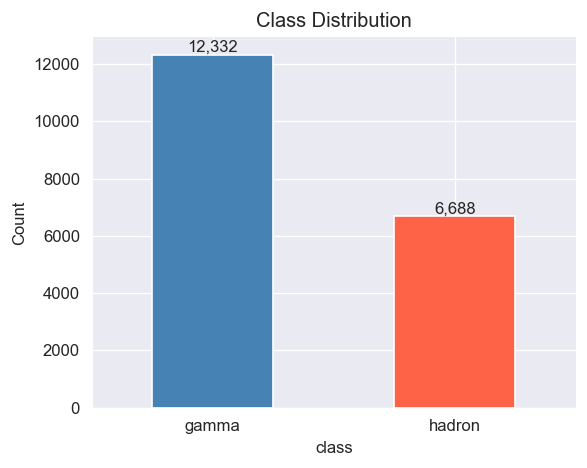

In [10]:
LABEL_MAP = {1: 'gamma', 0: 'hadron'}
PALETTE = {1: 'steelblue', 0: 'tomato'}

count = df['class'].map(LABEL_MAP).value_counts()
fig, ax = plt.subplots(figsize=(5,4))
count.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                 (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()

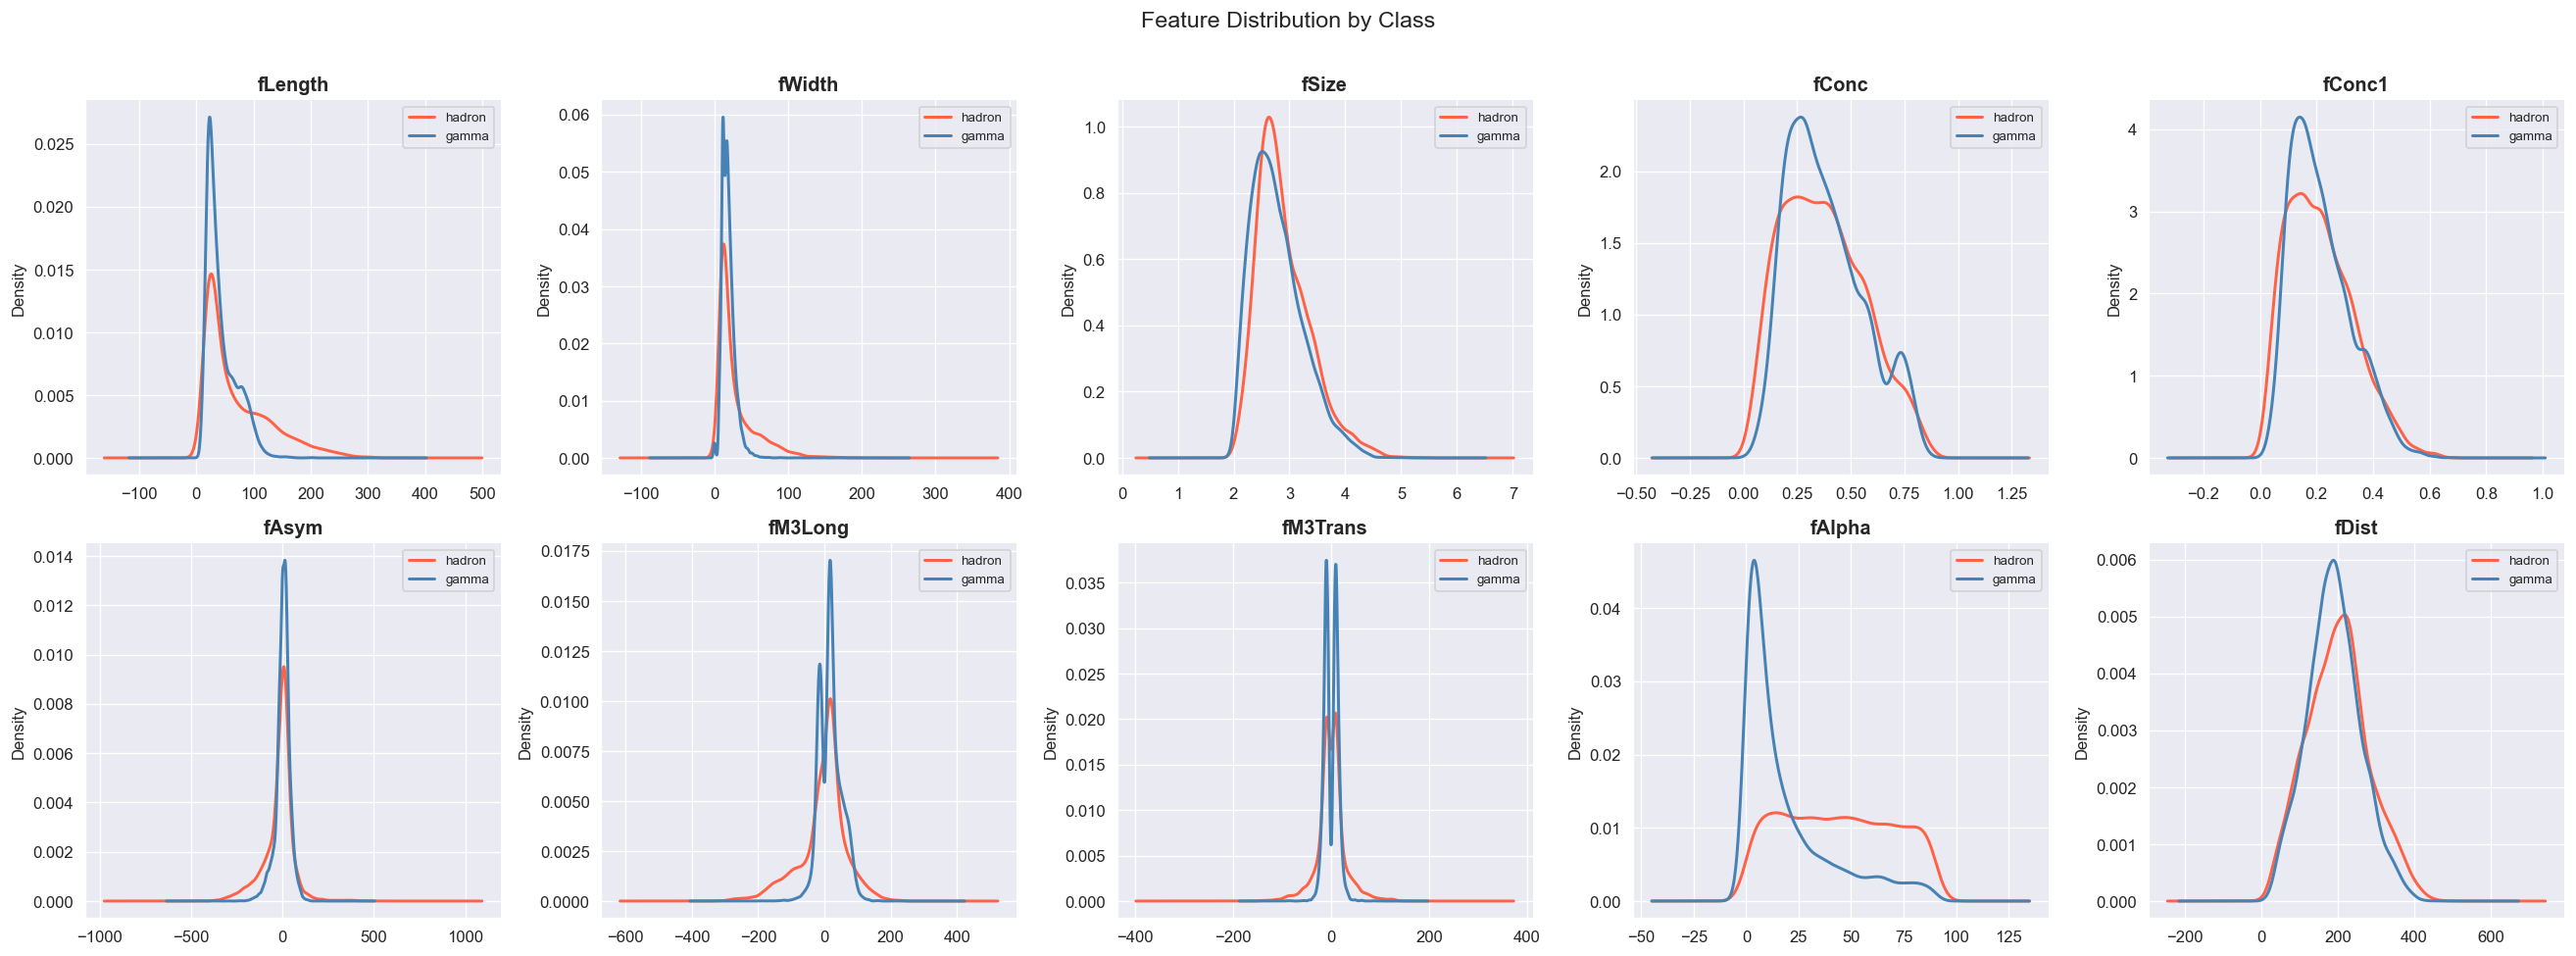

In [11]:
features = [c for c in df.columns if c != 'class']
fig, axes = plt.subplots(2,5, figsize=(22,8))
for ax, col in zip(axes.flat, features):
    for label, grp in df.groupby('class'):
        grp[col].plot(kind='kde', ax=ax, label=LABEL_MAP[label],
                      color=PALETTE[label], linewidth=1.8)
        ax.set_title(col, fontweight='bold')
        ax.set_xlabel('')
        ax.legend(fontsize=8)
fig.suptitle('Feature Distribution by Class', fontsize=14, y=1.01)
plt.tight_layout()

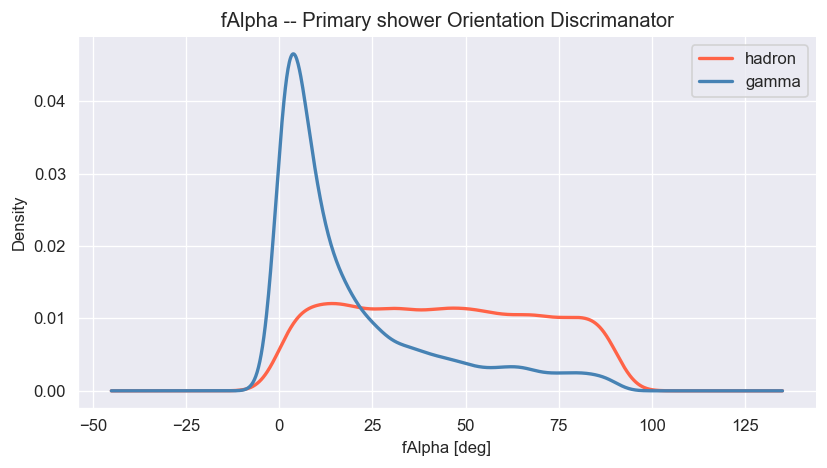

In [12]:
fig, ax = plt.subplots(figsize=(7,4))
for label, grp in df.groupby('class'):
    grp['fAlpha'].plot(kind='kde', ax=ax, label=LABEL_MAP[label], color=PALETTE[label], linewidth=2)
ax.set_title('fAlpha -- Primary shower Orientation Discrimanator')
ax.set_xlabel('fAlpha [deg]')
ax.legend()
plt.tight_layout()

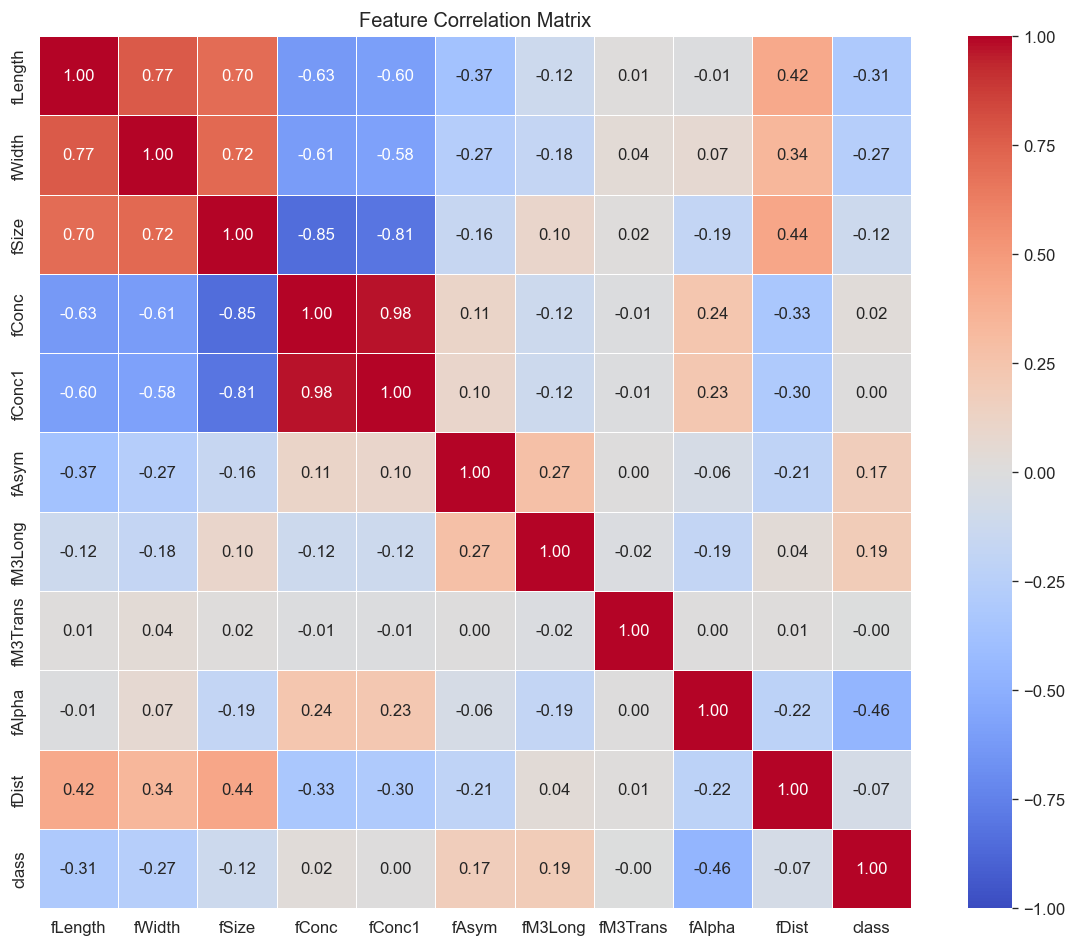

In [13]:
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax, square=True, linewidths=.5, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()

Preprocessing

In [14]:
x, y = df.drop('class', axis=1), df['class']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler =  StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

print(f'Train : {x_train_s.shape}, Test : {x_test_s.shape}')
print(f'Train gamma ratio: {y_train.mean():.2%}')

Train : (15216, 10), Test : (3804, 10)
Train gamma ratio: 64.88%


Models

In [15]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

rf = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg/pos,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

rf.fit(x_train_s, y_train)
xgb.fit(x_train_s, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

Evaluation

In [16]:
LABELS = ['hadron', 'gamma']

def evaluate(name, model, x, y):
    y_pred = model.predict(x)
    y_prob = model.predict_proba(x)[:,1]
    print(classification_report(y, y_pred, target_names=LABELS))
    print(f'ROC-AOC :{roc_auc_score(y, y_prob):.4f}')
    print(f'PR-AUC :{average_precision_score(y, y_prob):.4f}')
    return y_pred, y_prob

rf_pred, rf_prob = evaluate('Random Forest', rf, x_test_s, y_test)
xgb_pred, xgb_prob = evaluate('XGBoost', xgb, x_test_s, y_test)

              precision    recall  f1-score   support

      hadron       0.88      0.76      0.82      1344
       gamma       0.88      0.95      0.91      2460

    accuracy                           0.88      3804
   macro avg       0.88      0.86      0.87      3804
weighted avg       0.88      0.88      0.88      3804

ROC-AOC :0.9333
PR-AUC :0.9559
              precision    recall  f1-score   support

      hadron       0.85      0.81      0.83      1344
       gamma       0.90      0.92      0.91      2460

    accuracy                           0.88      3804
   macro avg       0.88      0.87      0.87      3804
weighted avg       0.88      0.88      0.88      3804

ROC-AOC :0.9339
PR-AUC :0.9544


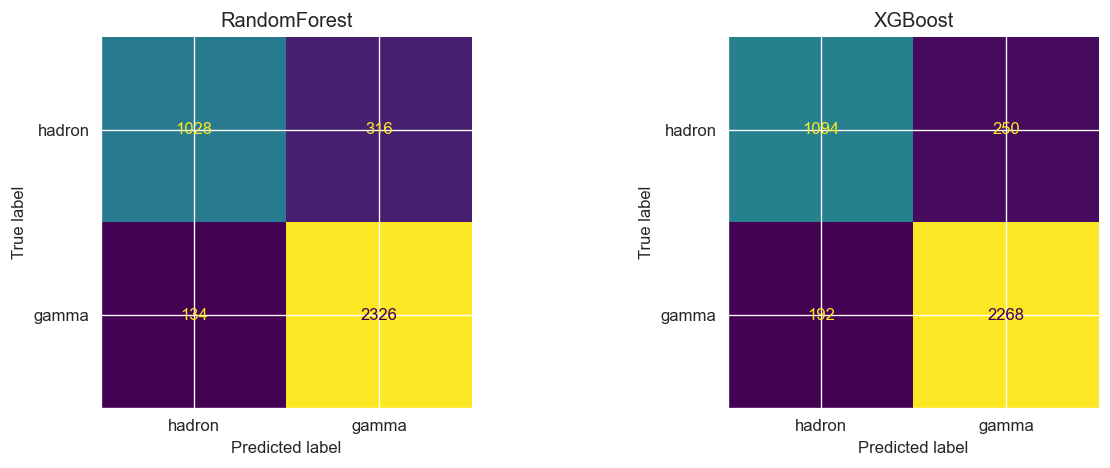

In [18]:
fig, axes = plt.subplots(1,2, figsize=(11,4))
for ax, (name, y_pred) in zip(axes, [('RandomForest', rf_pred), ('XGBoost', xgb_pred)]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=LABELS, ax=ax, colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()

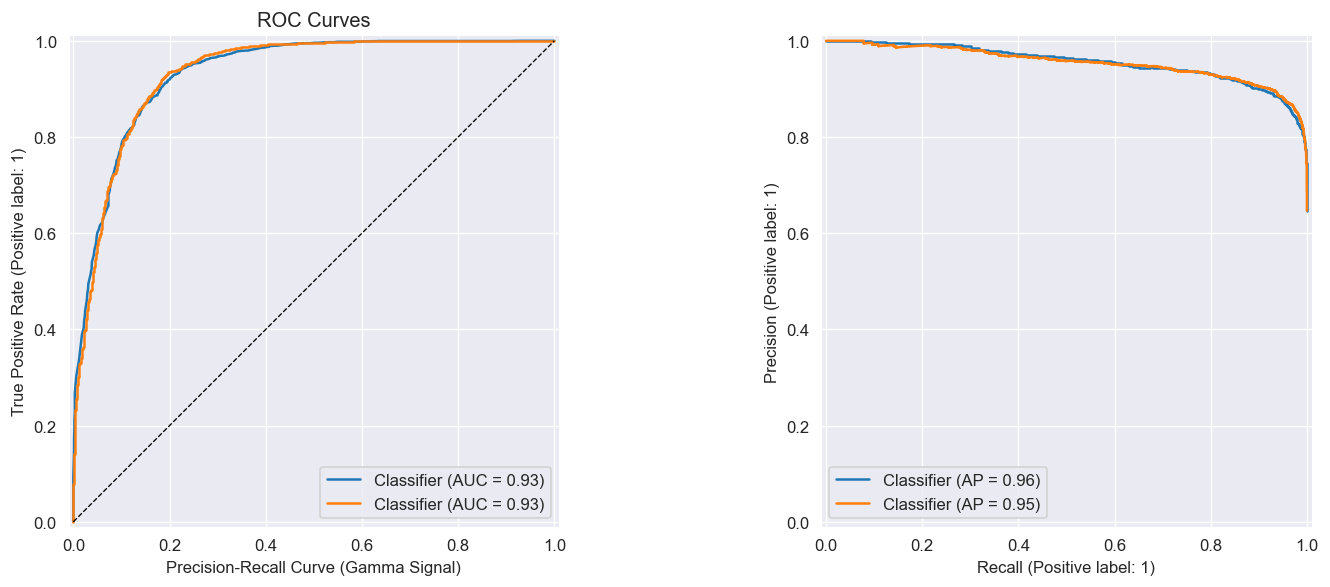

In [19]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(13, 5))

for name, y_prob in [('RandomForest', rf_prob), ('XGBoost', xgb_prob)]:
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax1)
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax2)

ax1.plot([0,1], [0,1], 'k--', linewidth=0.8)
ax1.set_title('ROC Curves')
ax1.set_xlabel('Precision-Recall Curve (Gamma Signal)')
plt.tight_layout()

Feature Importance

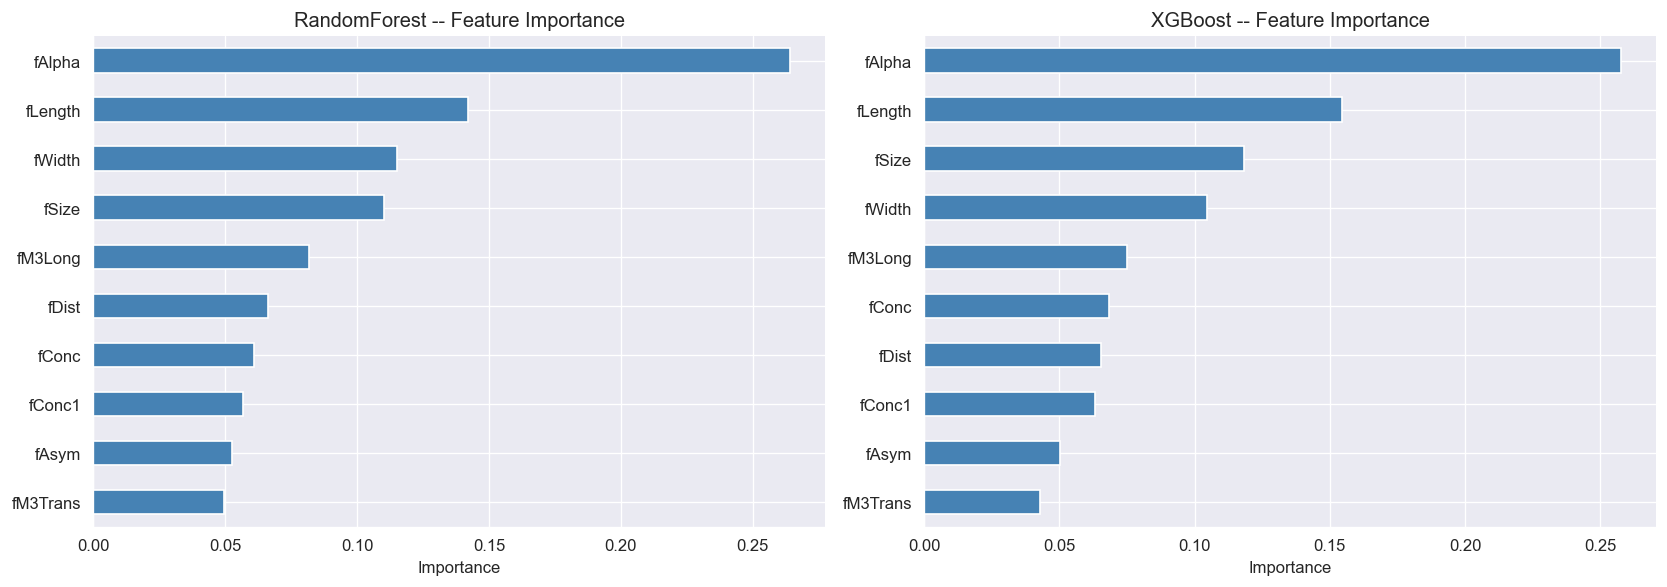

In [20]:
fig, axes = plt.subplots(1,2, figsize=(14, 5))
for ax, (name, model) in zip(axes, [('RandomForest', rf), ('XGBoost', xgb)]):
    imp = pd.Series(model.feature_importances_, index=x.columns).sort_values()
    imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{name} -- Feature Importance')
    ax.set_xlabel('Importance')
plt.tight_layout()

In [21]:
summary = pd.DataFrame({
    'Model'  : ['Random Forest', 'XGBoost'],
    'ROC-AUC': [roc_auc_score(y_test, rf_prob), roc_auc_score(y_test, xgb_prob)],
    'PR-AUC' : [average_precision_score(y_test, rf_prob), average_precision_score(y_test, xgb_prob)],
}).set_index('Model')
summary

,ROC-AUC,PR-AUC
Model,,
Random Forest,0.933331,0.955928
XGBoost,0.933862,0.954440
